# Exponential Disk in a Dark Matter Halo

We sample an exponential disk in approximate equilibrium inside a flat-rotation-curve halo,
then evolve it with `ezfalcon` to verify stability.

**Key physics:**
- Positions: $\Sigma(R) = \Sigma_0 e^{-R/R_d}$, vertical sech$^2(z/z_0)$
- Frequencies: flat RC gives $\Omega = v_c/R$, $\kappa = \sqrt{2}\,\Omega$
- Dispersions: Toomre $Q = \sigma_R \kappa / (3.36\, G\, \Sigma)$ sets $\sigma_R$; epicyclic ratio gives $\sigma_\phi = \sigma_R/\sqrt{2}$
- Asymmetric drift: $\langle v_\phi \rangle < v_c$ from the radial Jeans equation

In [1]:
from ezfalcon.simulation import Sim
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import interp1d
from astropy import units as u, constants as const
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

plt.rcParams.update({
    'xtick.direction': 'in', 'ytick.direction': 'in',
    'font.size': 14, 'axes.labelsize': 16,
    'xtick.major.width': 1.5, 'ytick.major.width': 1.5,
    'ytick.right': True, 'xtick.top': True,
    'mathtext.fontset': 'stix',
    'xtick.minor.visible': True, 'ytick.minor.visible': True,
})

In [2]:
def sample_exponential_disk(N, sigma0, Rd, z0, vc_halo, Q_target=1.5, seed=None):
    """
    Sample an exponential disk in approximate equilibrium within a
    flat-rotation-curve halo.

    Assumes the halo dominates the rotation curve (vc ~ const), giving
    analytical epicyclic frequencies.  All velocity dispersions and the
    asymmetric drift correction follow from the radial Jeans equation.

    Parameters
    ----------
    N : int
        Number of particles.
    sigma0 : Quantity [surface density]
        Central surface density.
    Rd : Quantity [length]
        Radial scale length.
    z0 : Quantity [length]
        Vertical scale height (sech^2 profile).
    vc_halo : Quantity [velocity]
        Flat halo circular velocity.
    Q_target : float
        Target Toomre Q (> 1 for axisymmetric stability).
    seed : int, optional
        Random seed for reproducibility.

    Returns
    -------
    pos : (N, 3) Quantity [kpc]
    vel : (N, 3) Quantity [km/s]
    mass : (N,) Quantity [Msun]
    """
    rng = np.random.default_rng(seed)
    Rd_val = Rd.to(u.kpc).value
    M_disk = (2 * np.pi * sigma0 * Rd**2).to(u.Msun)

    # ── Positions ─────────────────────────────────────────────────────
    # R from inverse CDF of Σ(R) = Σ₀ exp(-R/Rd):
    #   P(< R) = 1 − (1 + R/Rd) exp(−R/Rd)
    r_ax = np.linspace(0.001 * Rd_val, 12 * Rd_val, 5000)
    cdf = 1 - (1 + r_ax / Rd_val) * np.exp(-r_ax / Rd_val)
    inv_cdf = interp1d(cdf, r_ax)
    R = inv_cdf(rng.uniform(0, cdf[-1], N)) * u.kpc

    phi = rng.uniform(0, 2 * np.pi, N)
    x = R * np.cos(phi)
    y = R * np.sin(phi)

    # z from sech² profile: CDF⁻¹(p) = z₀ arctanh(2p − 1)
    u_z = np.clip(2 * rng.uniform(size=N) - 1, -1 + 1e-15, 1 - 1e-15)
    z = z0 * np.arctanh(u_z)

    # ── Frequencies (flat rotation curve) ─────────────────────────────
    Omega = vc_halo / R                    # circular frequency
    kappa = np.sqrt(2) * Omega             # epicyclic frequency

    # ── Velocity dispersions ──────────────────────────────────────────
    Sigma = sigma0 * np.exp(-R / Rd)       # surface density at R

    # Radial: determined by Toomre Q
    #   Q = σ_R κ / (3.36 G Σ)  =>  σ_R = Q × 3.36 G Σ / κ
    sigma_R = (Q_target * 3.36 * const.G * Sigma / kappa).to(u.km / u.s)

    # Azimuthal: epicyclic approximation  σ_φ = σ_R × κ/(2Ω) = σ_R/√2
    sigma_phi = sigma_R / np.sqrt(2)

    # Vertical: self-gravitating isothermal sheet  σ_z² = π G Σ z₀ / 2
    sigma_z = np.sqrt(np.pi * const.G * Sigma * z0 / 2).to(u.km / u.s)

    # ── Mean azimuthal velocity (asymmetric drift) ────────────────────
    # ⟨v_φ⟩² = v_c² + σ_R² [d ln(Σ σ_R²)/d ln R  +  1  −  κ²/(4Ω²)]
    #
    # With Q = const and flat RC:
    #   σ_R ∝ Σ R  =>  Σ σ_R² ∝ Σ³ R²
    #   d ln(Σ σ_R²)/d ln R = −3R/Rd + 2
    #   κ²/(4Ω²) = 1/2
    dlnf_dlnR = -3 * R / Rd + 2
    drift_correction = sigma_R**2 * (dlnf_dlnR + 1 - 0.5)
    vphi_mean = np.sqrt(
        np.maximum(vc_halo**2 + drift_correction, 0 * u.km**2 / u.s**2)
    ).to(u.km / u.s)

    # ── Sample velocities ─────────────────────────────────────────────
    vphi = vphi_mean + sigma_phi.to(u.km / u.s) * rng.normal(size=N)
    vR   = sigma_R.to(u.km / u.s) * rng.normal(size=N)
    vz_s = sigma_z.to(u.km / u.s) * rng.normal(size=N)

    # Cylindrical → Cartesian
    vx = -vphi * np.sin(phi) + vR * np.cos(phi)
    vy =  vphi * np.cos(phi) + vR * np.sin(phi)

    # ── Assemble and center ───────────────────────────────────────────
    pos  = np.vstack((x, y, z)).T
    vel  = np.vstack((vx, vy, vz_s)).T
    mass = np.ones(N) * M_disk / N

    pos -= np.mean(pos, axis=0)
    vel -= np.mean(vel, axis=0)

    return pos, vel, mass

## Parameters

In [3]:
N        = 20_000
sigma0   = 50 * u.Msun / u.pc**2      # central surface density
Rd       = 3.0 * u.kpc                 # scale length
z0       = 0.3 * u.kpc                 # scale height
vc_halo  = 220 * u.km / u.s            # flat halo circular velocity
Q        = 1.5                          # Toomre Q

M_disk = (2 * np.pi * sigma0 * Rd**2).to(u.Msun)
T_orb  = (2 * np.pi * Rd / vc_halo).to(u.Myr)  # orbital period at Rd
print(f'Disk mass:   {M_disk:.2e}')
print(f'T_orb(Rd):   {T_orb:.1f}')

Disk mass:   2.83e+09 solMass
T_orb(Rd):   83.8 Myr


## Generate Initial Conditions

In [4]:
pos, vel, mass = sample_exponential_disk(
    N, sigma0, Rd, z0, vc_halo, Q_target=Q, seed=42
)

ok = np.isfinite(pos).all(axis=1) & np.isfinite(vel).all(axis=1)
print(f'Particles OK: {ok.sum()}/{N}')
pos, vel, mass = pos[ok], vel[ok], mass[ok]

Particles OK: 20000/20000


## Verify the ICs

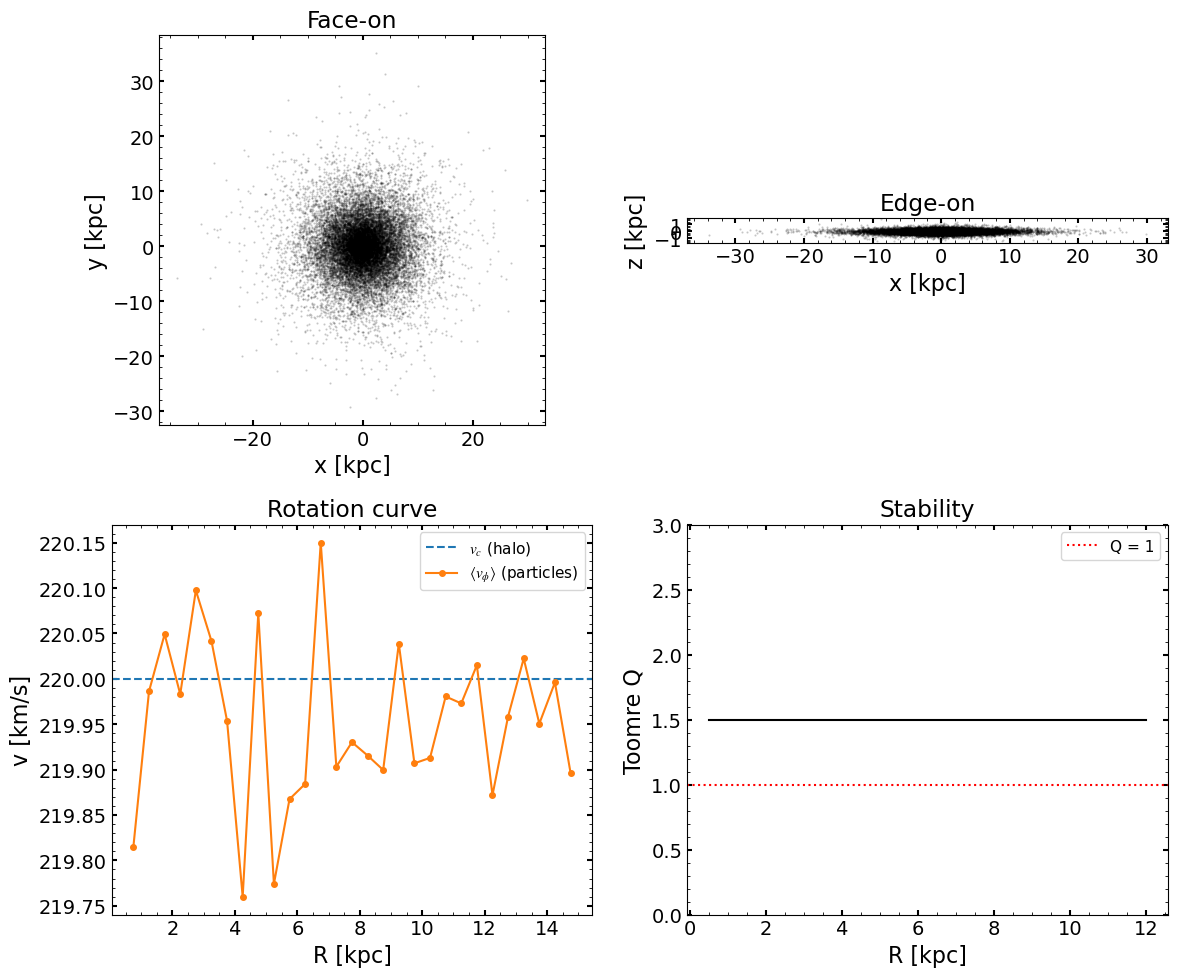

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# --- Face-on and edge-on ---
axes[0, 0].scatter(pos[:, 0].value, pos[:, 1].value, s=0.3, c='k', alpha=0.2)
axes[0, 0].set(xlabel='x [kpc]', ylabel='y [kpc]', title='Face-on', aspect='equal')
axes[0, 1].scatter(pos[:, 0].value, pos[:, 2].value, s=0.3, c='k', alpha=0.2)
axes[0, 1].set(xlabel='x [kpc]', ylabel='z [kpc]', title='Edge-on', aspect='equal')

# --- Rotation curve and mean vphi ---
R_particles = np.sqrt(pos[:, 0]**2 + pos[:, 1]**2).to(u.kpc).value
vphi_particles = (-vel[:, 0] * np.sin(np.arctan2(pos[:, 1], pos[:, 0]))
                  + vel[:, 1] * np.cos(np.arctan2(pos[:, 1], pos[:, 0]))).to(u.km/u.s).value

R_bins = np.linspace(0.5, 15, 30)
R_mid = 0.5 * (R_bins[:-1] + R_bins[1:])
vphi_binned = np.array([np.mean(vphi_particles[(R_particles > R_bins[i]) & (R_particles < R_bins[i+1])])
                        for i in range(len(R_bins) - 1)])

axes[1, 0].axhline(vc_halo.to(u.km/u.s).value, color='C0', ls='--', label=r'$v_c$ (halo)')
axes[1, 0].plot(R_mid, vphi_binned, 'C1o-', ms=4, label=r'$\langle v_\phi \rangle$ (particles)')
axes[1, 0].set(xlabel='R [kpc]', ylabel='v [km/s]', title='Rotation curve')
axes[1, 0].legend(fontsize=11)

# --- Toomre Q profile ---
R_q = np.linspace(0.5, 12, 200) * u.kpc
Sigma_q = sigma0 * np.exp(-R_q / Rd)
kappa_q = np.sqrt(2) * vc_halo / R_q
sigma_R_q = (Q * 3.36 * const.G * Sigma_q / kappa_q).to(u.km / u.s)
Q_profile = (sigma_R_q * kappa_q / (3.36 * const.G * Sigma_q)).decompose()

axes[1, 1].plot(R_q.value, Q_profile.value, 'k-')
axes[1, 1].axhline(1, color='r', ls=':', label='Q = 1')
axes[1, 1].set(xlabel='R [kpc]', ylabel='Toomre Q', title='Stability', ylim=(0, 3))
axes[1, 1].legend(fontsize=11)

fig.tight_layout()

## Run Simulation

Evolve for ~6 orbital periods at $R_d$ with self-gravity + external halo.

In [6]:
from galpy.potential import LogarithmicHaloPotential

sim = Sim()
sim.add_particles('stars',
                   pos.to(u.kpc).value,
                   vel.to(u.kpc / u.Myr).value,
                   mass.to(u.Msun).value)

# Logarithmic halo: Φ = (vc²/2) ln(Rc² + R² + z²)
halo = LogarithmicHaloPotential(amp=vc_halo**2, core=0.01 * u.kpc)
sim.add_external_pot('halo', halo)

sim.run(t_end=500, dt=0.1, dt_out=5, eps=0.2, theta=0.5)

100%|██████████| 5000/5000 [02:21<00:00, 35.40it/s]


## Final Snapshot

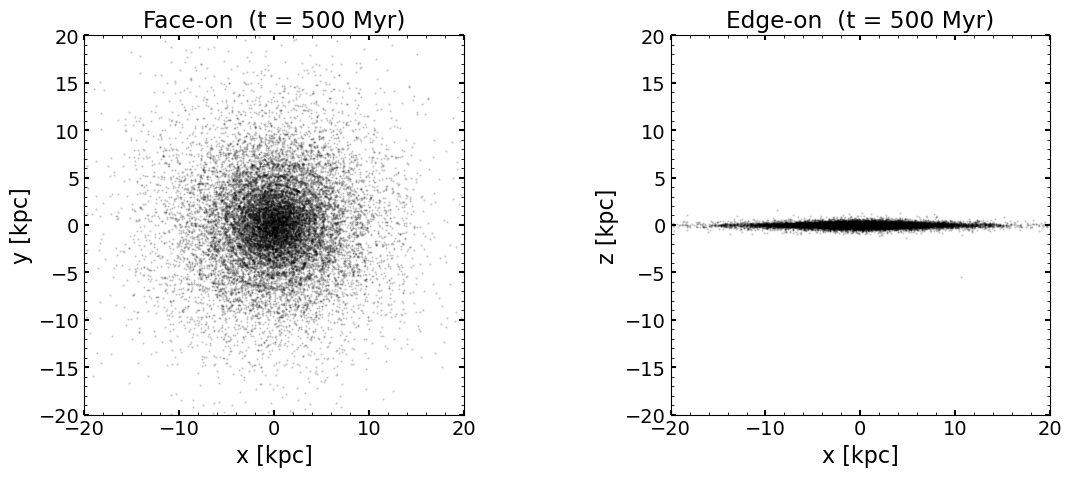

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
lim = 20

axes[0].scatter(sim.x(t=-1), sim.y(t=-1), s=0.3, c='k', alpha=0.2)
axes[0].set(xlabel='x [kpc]', ylabel='y [kpc]', title='Face-on  (t = 500 Myr)',
            xlim=(-lim, lim), ylim=(-lim, lim), aspect='equal')

axes[1].scatter(sim.x(t=-1), sim.z(t=-1), s=0.3, c='k', alpha=0.2)
axes[1].set(xlabel='x [kpc]', ylabel='z [kpc]', title='Edge-on  (t = 500 Myr)',
            xlim=(-lim, lim), ylim=(-lim, lim), aspect='equal')

fig.tight_layout()

## Animation

In [8]:
# times = sim.times
# lim = 25

# fig, axes = plt.subplots(1, 2, figsize=(12, 5))
# sc1 = axes[0].scatter([], [], s=0.5, c='k', alpha=0.3)
# sc2 = axes[1].scatter([], [], s=0.5, c='k', alpha=0.3)

# for ax, lbl in zip(axes, ['Face-on (x–y)', 'Edge-on (x–z)']):
#     ax.set(xlim=(-lim, lim), ylim=(-lim, lim), aspect='equal', title=lbl)

# axes[0].set(xlabel='x [kpc]', ylabel='y [kpc]')
# axes[1].set(xlabel='x [kpc]', ylabel='z [kpc]')
# title = fig.suptitle('')

# def update(i):
#     sc1.set_offsets(np.c_[sim.x(t=i), sim.y(t=i)])
#     sc2.set_offsets(np.c_[sim.x(t=i), sim.z(t=i)])
#     title.set_text(f't = {times[i]:.0f} Myr')
#     return sc1, sc2, title

# ani = FuncAnimation(fig, update, frames=len(times)//3, interval=300, blit=True)
# plt.close(fig)
# HTML(ani.to_jshtml())

## 3D Animation

In [ ]:
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

lim = 20
skip = 2
n_snaps = len(sim.times)

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')

sc = ax.scatter(sim.x(0), sim.y(0), sim.z(0), s=0.3, c='k', alpha=0.3, depthshade=True)
ax.set(xlim3d=(-lim, lim), ylim3d=(-lim, lim), zlim3d=(-lim/4, lim/4),
       xlabel='x [kpc]', ylabel='y [kpc]', zlabel='z [kpc]')
ax.set_box_aspect([1, 1, 0.25])
title = ax.set_title(f't = {sim.times[0]:.0f} Myr')

def update(frame):
    idx = frame * skip
    xs, ys, zs = sim.x(idx), sim.y(idx), sim.z(idx)
    sc._offsets3d = (xs, ys, zs)
    title.set_text(f't = {sim.times[idx]:.0f} Myr')
    return sc, title

ani = FuncAnimation(fig, update, frames=n_snaps // skip, interval=200)
plt.close(fig)
HTML(ani.to_jshtml())

## Energy Conservation

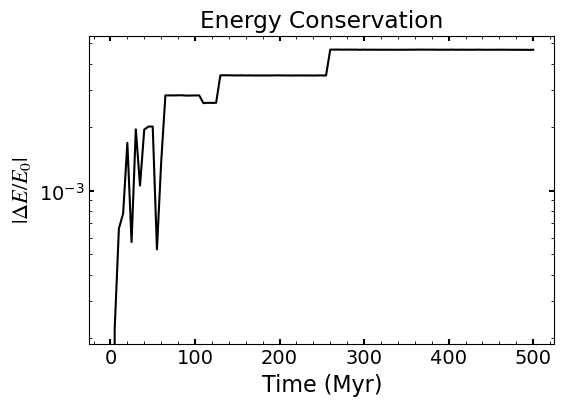

In [9]:
sim.plot_diagnostic()